IHD with 36 sujects, 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import os
import warnings
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)


plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.loc'] = 'best'

plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 8  # Taille des labels des xticks
plt.rcParams['ytick.labelsize'] = 8  # Taille des labels des yticks
plt.rcParams['legend.fontsize'] = 8 # Taille des labels de la légende
plt.rcParams['figure.titlesize'] = 12  # Taille du titre de la figure
plt.rcParams['axes.titlesize'] = 12  # Taille du titre des sous-graphes
plt.rcParams['axes.labelsize'] = 10  # Taille des labels des axes


pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'
# pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
pathfig=pathfile+'figures/'
os.chdir(pathfile)

addtotitle='_03022026_woMA_for_RD_MD_AD_FA' # to specify the version of the data

metricsDTI='FA' # to specify the DTI metric to use for the analysis FA, RD, AD, MD

### change 36 to 42 to include the 6 subjects without IHD in the analysis
limitsubject=36 # to select only the 36 subjects with IHD


#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
scaler = RobustScaler()


DTI_all=np.zeros((limitsubject, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((limitsubject, 98, 7))  # 10 DTI metrics

for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_{metricsDTI}{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")

    DTI_all[:,:,i]=dfCCx[:limitsubject].values  ## une variable DTI of shape subjects x nodes x n CC
    
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx[:limitsubject].values)  ## une variable DTI of shape subjects x nodes x n CC

 # target var

import seaborn as sns
selection=[0,limitsubject] # to select only the subjects with IHD
Aging_INDICES=Aging_INDICES_all[selection[0]:selection[1]] # 

DTI=DTI_all[selection[0]:selection[1],:,:]  # 

DTI_scaled=DTI_all_scaled[selection[0]:selection[1],:,:]  

age = Aging_INDICES['age'].values

### ATTENTION CIBLE IHD REMPLACANT JND
ihd = Aging_INDICES['IHD'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['IHD_group'] = pd.qcut(Aging_INDICES['IHD'], q=2, labels=labels)
Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
IHD_grouped = Aging_INDICES['IHD_group']
JND_grouped = Aging_INDICES['JND_group']

Aging_INDICES=Aging_INDICES[0:limitsubject] # only the subjects with IHD

print('length of Aging_INDICES:', len(Aging_INDICES))

DTI_scaled_saved=DTI_scaled.copy() # to keep a copy of the original DTI values before adjustment


##############

import statsmodels.api as sm

DTI_adjusted = np.zeros_like(DTI_scaled)  # pour stocker les données DTI ajustées

for cc in range(7):
    for seg in range(98):
        data = DTI_scaled[:,seg,cc]  # on prend les données DTI du CC1 pour l'exemple
        data_adjusted = data.copy()
        X = sm.add_constant(age)
        y = data
        model = sm.OLS(y, X)
        results = model.fit()   
        residuals = results.resid
        data_adjusted = residuals

        DTI_adjusted[:,seg,cc] = data_adjusted  # stocker les données ajustées  


FileNotFoundError: [WinError 3] Le chemin d’accès spécifié est introuvable: '/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'

F-value: 12.29629170543671, p-value: 0.0012971267549069566


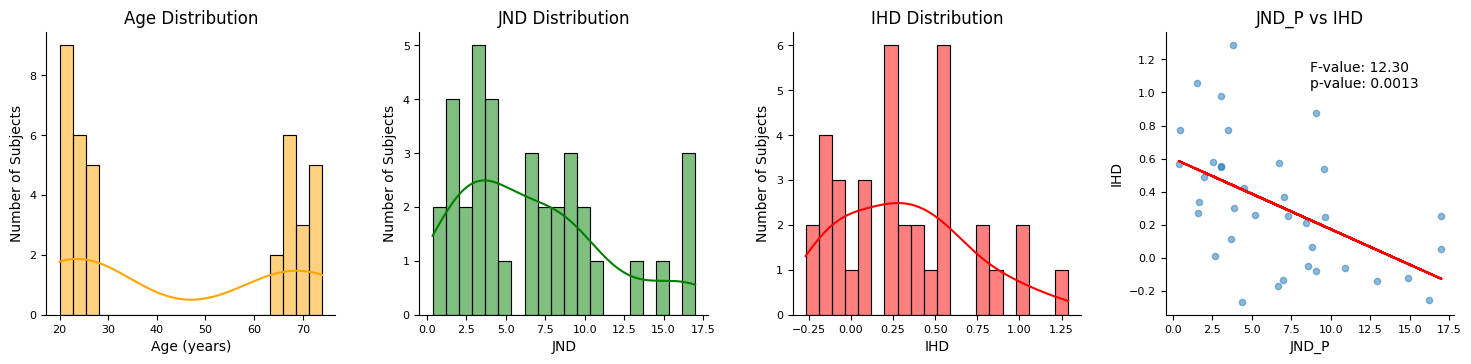

In [139]:
from sklearn.feature_selection import f_regression

fig2, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 4))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND Distribution')
axs[1].set_xlabel('JND')
axs[1].set_ylabel('Number of Subjects')
sns.histplot(ihd, bins=20, ax=axs[2],color='red',kde=True)
axs[2].set_title('IHD Distribution')
axs[2].set_xlabel('IHD')
axs[2].set_ylabel('Number of Subjects')


axs[3].scatter(jnd, ihd, alpha=0.5, s=20)
axs[3].set_title('JND_P vs IHD')
axs[3].set_xlabel('JND_P')
axs[3].set_ylabel('IHD')

coefficients = np.polyfit(jnd, ihd, 1)
polynomial = np.poly1d(coefficients)

f,p=f_regression(jnd.reshape(-1, 1), ihd)

print(f"F-value: {f[0]}, p-value: {p[0]}")
# Tracer les données et la régression linéaire
axs[3].plot(jnd, polynomial(jnd), color='red', label='Régression linéaire')
axs[3].text(0.5, 0.9, f'F-value: {f[0]:.2f}\np-value: {p[0]:.4f}', transform=axs[3].transAxes, fontsize=10, verticalalignment='top')
for i in range(4):
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']




In [140]:
print('DTI shape:', DTI.shape)
print('Aging_INDICES shape:', Aging_INDICES.shape)

age_grouped = Aging_INDICES['group_O'].values
IHD_grouped = Aging_INDICES['IHD_group'].values
JND_grouped = Aging_INDICES['JND_group'].values


DTI shape: (36, 98, 7)
Aging_INDICES shape: (36, 9)


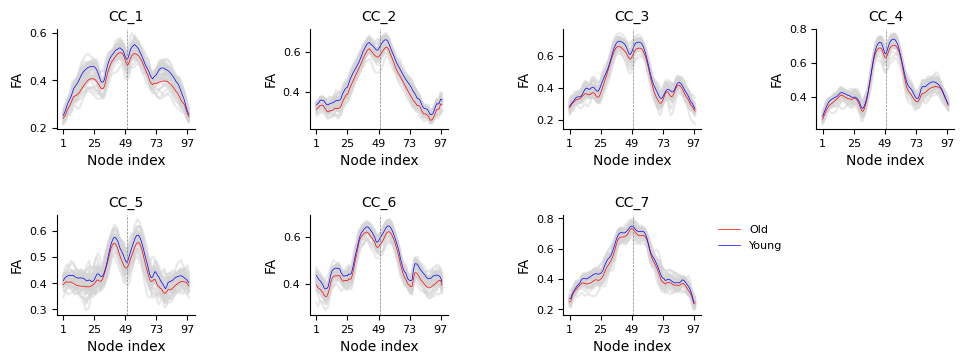

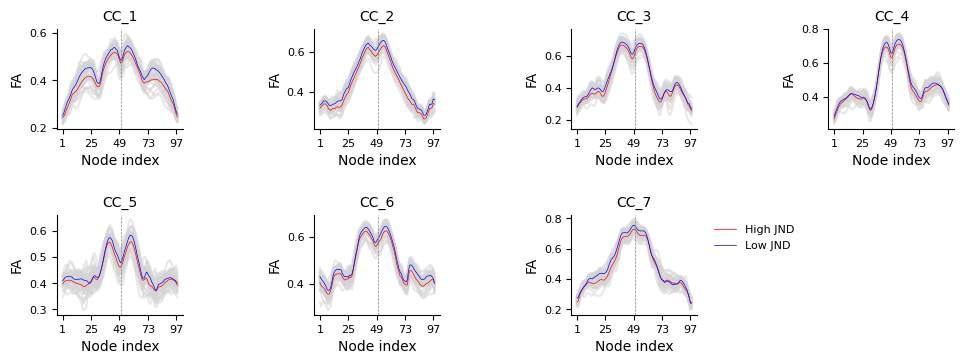

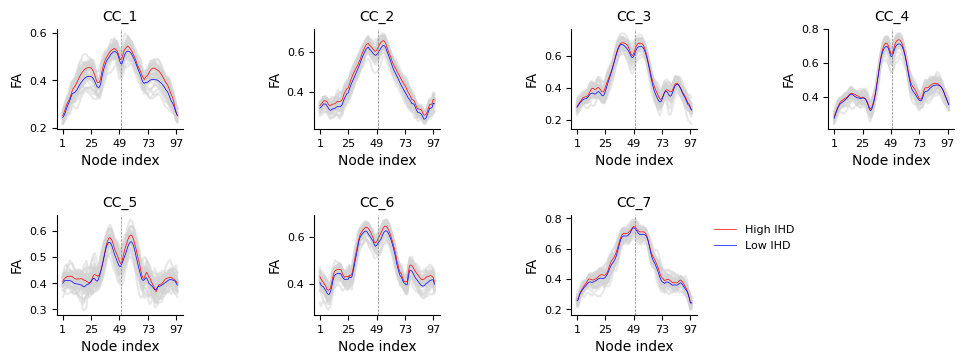

In [141]:

figsize=(10, 4)

fig3, axs = plt.subplots(nrows=2, ncols=4, figsize=figsize)
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[age_grouped==0,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[age_grouped==1,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[age_grouped==1,:,i].mean(axis=0), color='red', linewidth=0.5, label='Old')
    axs[i].plot(DTI[age_grouped==0,:,i].mean(axis=0), color='blue', linewidth=0.5, label='Young')
    axs[i].set_xlabel('Node index')
    axs[i].set_xticks(np.arange(0, 100, 24))
    axs[i].set_xticklabels(np.arange(1, 100, 24))
    axs[i].axvline(49, color='gray', linestyle='--', linewidth=0.5)
    axs[i].set_ylabel(metricsDTI)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx, fontsize=10)

axs[6].legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

fig3.delaxes(axs[7])
plt.tight_layout(pad=2.0)

########################################################################""

fig4, axs = plt.subplots(nrows=2, ncols=4, figsize=figsize)
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[JND_grouped==0,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[JND_grouped==1,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[JND_grouped==1,:,i].mean(axis=0), color='red', linewidth=0.5, label='High JND')
    axs[i].plot(DTI[JND_grouped==0,:,i].mean(axis=0), color='blue', linewidth=0.5, label='Low JND')
    axs[i].set_xlabel('Node index')
    axs[i].set_xticks(np.arange(0, 100, 24))
    axs[i].set_xticklabels(np.arange(1, 100, 24))
    axs[i].axvline(49, color='gray', linestyle='--', linewidth=0.5)
    axs[i].set_ylabel(metricsDTI)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx, fontsize=10)

axs[6].legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
fig4.delaxes(axs[7])

plt.tight_layout(pad=2.0)

########################################################################""
fig5, axs = plt.subplots(nrows=2, ncols=4, figsize=figsize)
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[IHD_grouped==0,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[IHD_grouped==1,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[IHD_grouped==1,:,i].mean(axis=0), color='red', linewidth=0.5, label='High IHD')
    axs[i].plot(DTI[IHD_grouped==0,:,i].mean(axis=0), color='blue', linewidth=0.5, label='Low IHD')
    axs[i].set_xlabel('Node index')
    axs[i].set_xticks(np.arange(0, 100, 24))
    axs[i].set_xticklabels(np.arange(1, 100, 24))
    axs[i].axvline(49, color='gray', linestyle='--', linewidth=0.5)
    axs[i].set_ylabel(metricsDTI)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx, fontsize=10)

axs[6].legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

fig5.delaxes(axs[7])
plt.tight_layout(pad=2.0)


Kruskal-Wallis H-statistic: 15.836148648648646, p-value: 6.90702732117708e-05


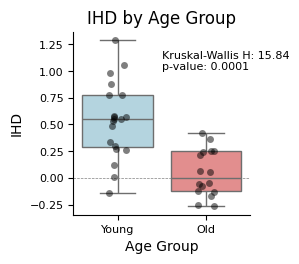

In [142]:
fig6, axs = plt.subplots(nrows=1, ncols=1, figsize=(3,3))

sns.boxplot(x=age_grouped, y=ihd, ax=axs, palette=['lightblue', 'lightcoral'], showfliers=False)
sns.stripplot(x=age_grouped, y=ihd, ax=axs, color='black', alpha=0.5, jitter=True)
axs.set_title('IHD by Age Group')
axs.set_xlabel('Age Group')
axs.set_ylabel('IHD')
axs.set_xticklabels(['Young', 'Old'])
axs.axhline(0, color='gray', linestyle='--', linewidth=0.5)


kstat, pval = stats.kruskal(ihd[age_grouped==0], ihd[age_grouped==1])
print(f"Kruskal-Wallis H-statistic: {kstat}, p-value: {pval}")

axs.text(0.5, 0.9, f'Kruskal-Wallis H: {kstat:.2f}\np-value: {pval:.4f}', transform=axs.transAxes, fontsize=8, verticalalignment='top')

plt.tight_layout(pad=2.0)

Kruskal-Wallis H-statistic: 15.587796086508742, p-value: 7.876130018398033e-05


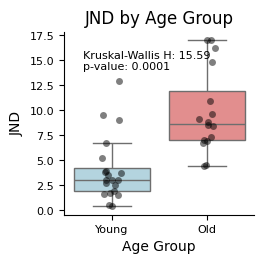

In [143]:
from scipy import stats

fig7, axs = plt.subplots(nrows=1, ncols=1, figsize=(3,3))

sns.boxplot(x=age_grouped, y=jnd, ax=axs, palette=['lightblue', 'lightcoral'], showfliers=False)
sns.stripplot(x=age_grouped, y=jnd, ax=axs, color='black', alpha=0.5, jitter=True)
axs.set_title('JND by Age Group')
axs.set_xlabel('Age Group')
axs.set_ylabel('JND')
axs.set_xticklabels(['Young', 'Old'])

kstat, pval = stats.kruskal(jnd[age_grouped==0], jnd[age_grouped==1])
print(f"Kruskal-Wallis H-statistic: {kstat}, p-value: {pval}")

axs.text(0.1, 0.9, f'Kruskal-Wallis H: {kstat:.2f}\np-value: {pval:.4f}', transform=axs.transAxes, fontsize=8, verticalalignment='top')

plt.tight_layout(pad=2.0)

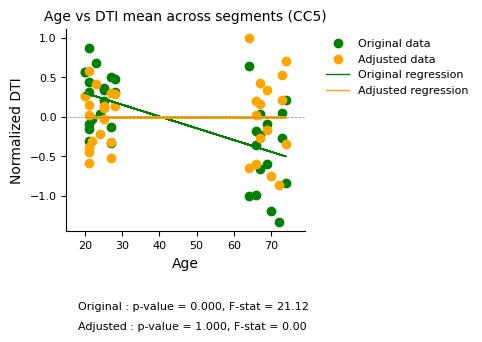

Kruskal-Wallis H-statistic: 12.263513513513516, p-value: 0.0004619010089922706
Kruskal-Wallis H-statistic: 0.009121621621630993, p-value: 0.9239119867263311


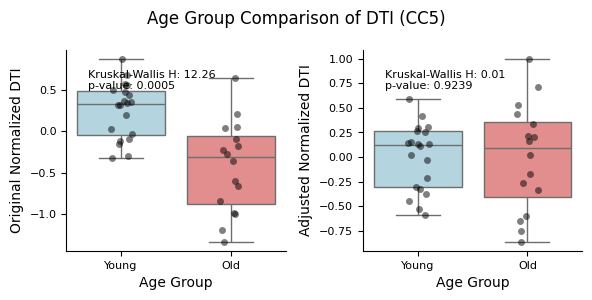

In [144]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cc=5 # CC5
DTI_to_use_scaled = DTI_scaled_saved[:, :, cc-1].mean(axis=1)  # Moyenne des 98 segments pour chaque sujet
DTI_to_use_adjusted = DTI_adjusted[:, :, cc-1].mean(axis=1)  # Moyenne des 98 segments pour chaque sujet

# Create a figure
fig8, ax8 = plt.subplots(figsize=(5,4))

# Plot the original data
ax8.plot(age, DTI_to_use_scaled, 'o', label='Original data', color='green')
ax8.plot(age, DTI_to_use_adjusted, 'o', label='Adjusted data', color='orange')

slope_orig, intercept_orig, r_value_orig, p_value_orig, std_err_orig = stats.linregress(age, DTI_to_use_scaled)
line_orig = slope_orig * age + intercept_orig
ax8.plot(age, line_orig, label='Original regression', color='green',lw=1)
# Calculate and plot regression lines for adjusted data
slope_adj, intercept_adj, r_value_adj, p_value_adj, std_err_adj = stats.linregress(age, DTI_to_use_adjusted)
line_adj = slope_adj * age + intercept_adj
ax8.plot(age, line_adj,  label='Adjusted regression', color='orange',lw=1)

n = len(age)
F_stat_orig = (r_value_orig**2 / (1 - r_value_orig**2)) * (n - 2)
F_stat_adj = (r_value_adj**2 / (1 - r_value_adj**2)) * (n - 2)

# Add p-values and F-statistics as text on the figure
ax8.text(0.05, 0.95-1.3, f'Original : p-value = {p_value_orig:.3f}, F-stat = {F_stat_orig:.2f}',
         transform=ax8.transAxes, fontsize=8, verticalalignment='top')
ax8.text(0.05, 0.90-1.35, f'Adjusted : p-value = {p_value_adj:.3f}, F-stat = {F_stat_adj:.2f}',
         transform=ax8.transAxes, fontsize=8, verticalalignment='top')

ax8.set_title(f'Age vs DTI mean across segments (CC{cc})', fontsize=10)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
ax8.set_xlim(age.min() - 5, age.max() + 5)
ax8.set_xlabel('Age')
ax8.set_ylabel('Normalized DTI')
ax8.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax8.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

###############
fig9, ax9 = plt.subplots(nrows=1, ncols=2, figsize=(6,3))

sns.boxplot(x=age_grouped, y=DTI_to_use_scaled, ax=ax9[0], palette=['lightblue', 'lightcoral'], showfliers=False)
sns.stripplot(x=age_grouped, y=DTI_to_use_scaled, ax=ax9[0], color='black', alpha=0.5, jitter=True)
ax9[0].set_xlabel('Age Group')
ax9[0].set_ylabel('Original Normalized DTI')
ax9[0].set_xticklabels(['Young', 'Old'])
kstat, pval = stats.kruskal(DTI_to_use_scaled[age_grouped==0], DTI_to_use_scaled[age_grouped==1])
print(f"Kruskal-Wallis H-statistic: {kstat}, p-value: {pval}")
ax9[0].text(0.1, 0.9, f'Kruskal-Wallis H: {kstat:.2f}\np-value: {pval:.4f}', transform=ax9[0].transAxes, fontsize=8, verticalalignment='top')
plt.tight_layout(pad=2.0)

sns.boxplot(x=age_grouped, y=DTI_to_use_adjusted, ax=ax9[1], palette=['lightblue', 'lightcoral'], showfliers=False)
sns.stripplot(x=age_grouped, y=DTI_to_use_adjusted, ax=ax9[1], color='black', alpha=0.5, jitter=True)
ax9[1].set_xlabel('Age Group')
ax9[1].set_ylabel('Adjusted Normalized DTI')
ax9[1].set_xticklabels(['Young', 'Old'])
kstat, pval = stats.kruskal(DTI_to_use_adjusted[age_grouped==0], DTI_to_use_adjusted[age_grouped==1])
print(f"Kruskal-Wallis H-statistic: {kstat}, p-value: {pval}")
ax9[1].text(0.1, 0.9, f'Kruskal-Wallis H: {kstat:.2f}\np-value: {pval:.4f}', transform=ax9[1].transAxes, fontsize=8, verticalalignment='top')


fig9.suptitle(f'Age Group Comparison of DTI (CC{cc})')


plt.tight_layout(pad=1.0)

In [146]:
print(os.getcwd())

titre_pdf='Figures JND and IHD DESCRIBE.pdf'
with PdfPages(titre_pdf) as pdf:
    pdf.savefig(fig1)  # Ajoute la première figure
    pdf.savefig(fig2)  # Ajoute la deuxième figure
    pdf.savefig(fig3)  # Ajoute la troisième figure
    pdf.savefig(fig4)  # Ajoute la quatrième figure
    pdf.savefig(fig5)  # Ajoute la cinquième figure
    pdf.savefig(fig6)  # Ajoute la sixième figure
    pdf.savefig(fig7)  # Ajoute la septième figure
    pdf.savefig(fig8)  # Ajoute la huitième figure
    pdf.savefig(fig9)  # Ajoute la neuvième figure


/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC
